# Iris Flower Classification

This notebook loads the Iris dataset and trains multiple classification models to compare performance.

In [18]:
# Uncomment the following lines to install required libraries if they are not already installed:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
# Load the Iris dataset and convert it to a pandas DataFrame
iris = load_iris()

feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df = pd.DataFrame(iris.data, columns=feature_names)

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = [species_map[target] for target in iris.target]

X = df[feature_names]
y = iris.target

# Display the first and last rows of the DataFrame
print(df.head())
print(df.tail())

print(df.columns.tolist())
print(df['species'].value_counts())
print(X.shape, y.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0        

In [20]:
print('df.shape:')
print(df.shape)


df.shape:
(150, 5)


In [21]:
print('df.dtypes:')
print(df.dtypes)


df.dtypes:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


In [22]:
print('Null values by column:')
print(df.isnull().sum())
print('No null values found.' if df.isnull().sum().sum() == 0 else 'Null values present.')


Null values by column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
No null values found.


In [23]:
print('df.describe():')
print(df.describe())


df.describe():
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [24]:
print('species value counts:')
print(df['species'].value_counts())


species value counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


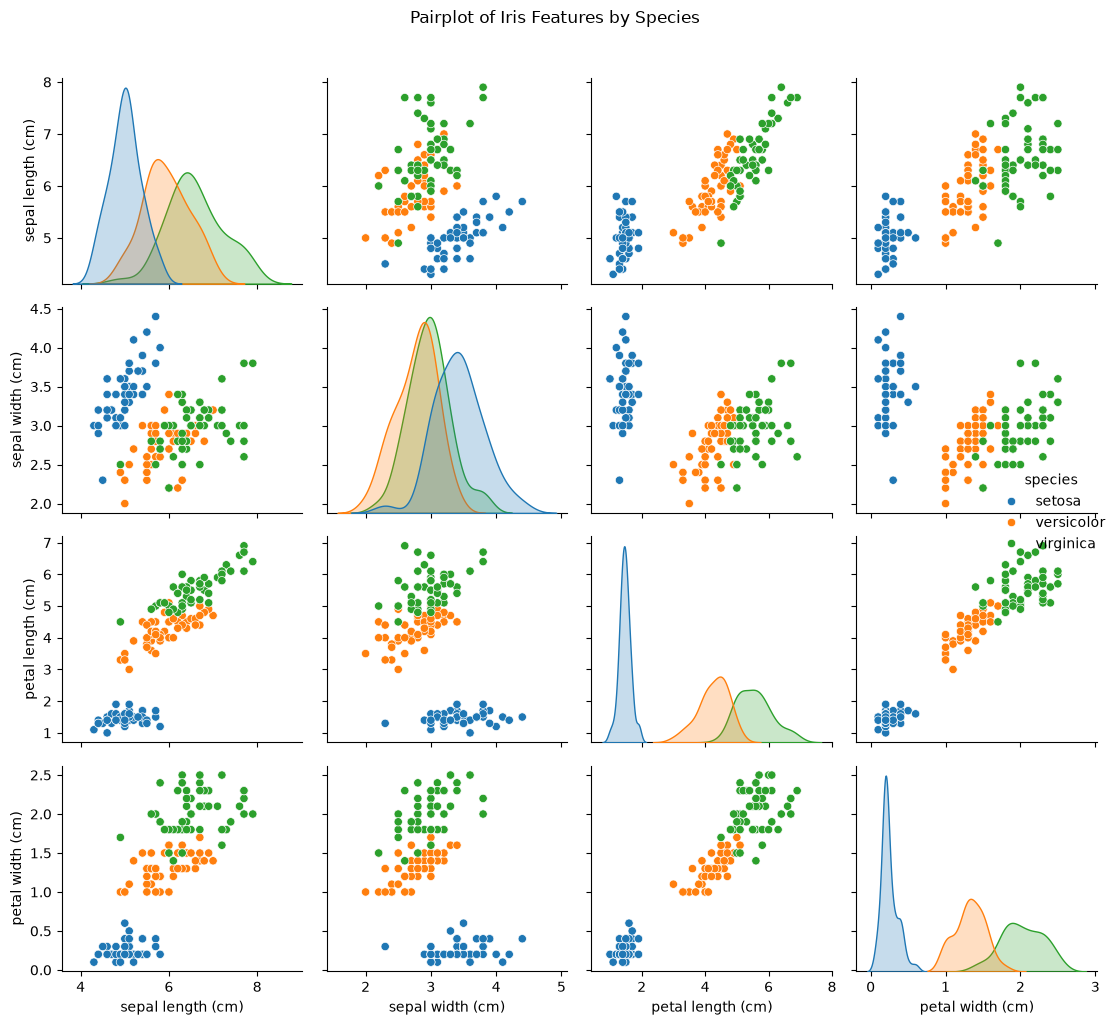

In [25]:
# Pairplot of all iris features by species
sns.pairplot(df, hue='species', corner=False)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.tight_layout()
plt.show()


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_31453/2778582610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=ax)


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_31453/2778582610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=ax)
/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_31453/2778582610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=ax)
/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_31453/2778582610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax

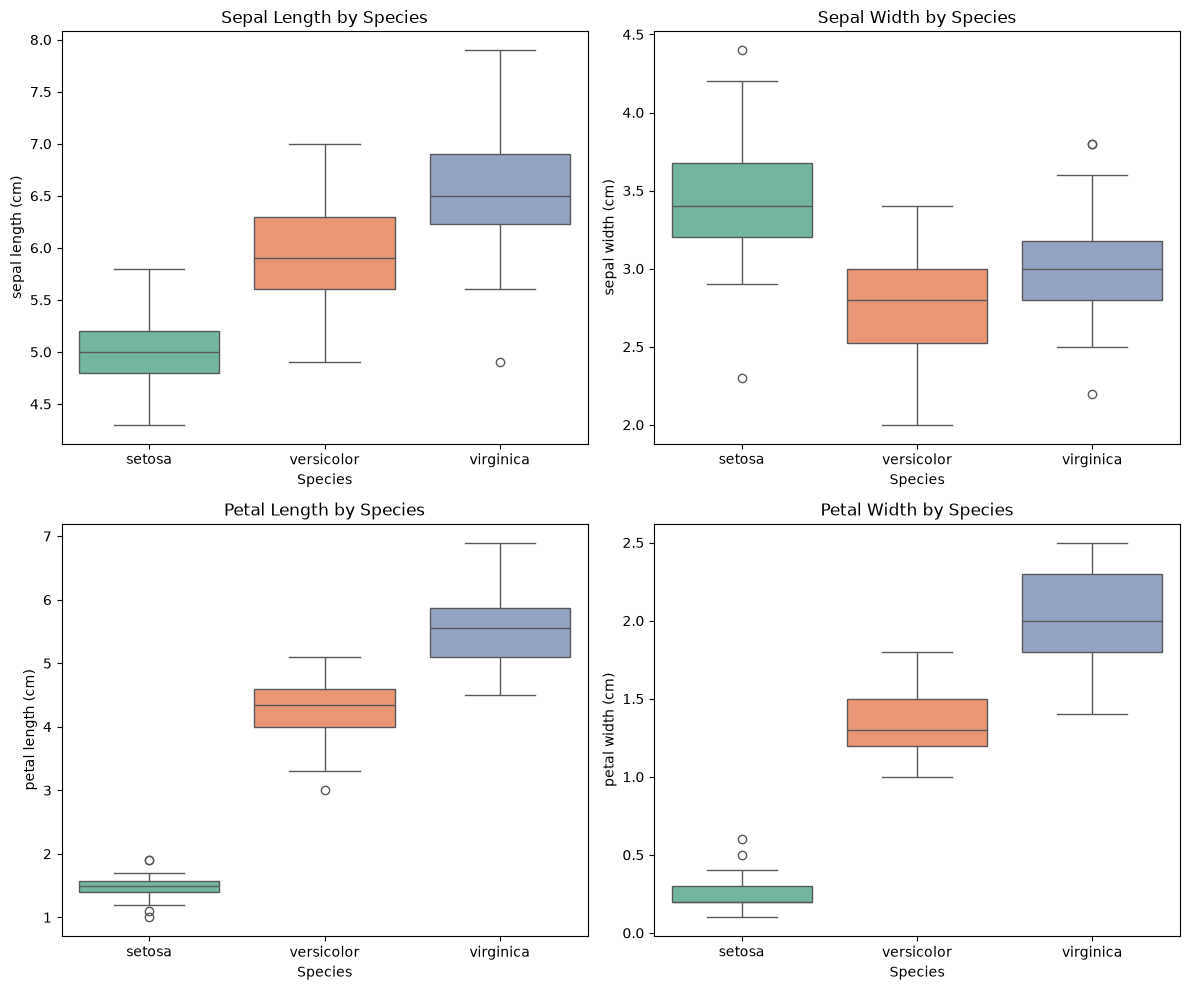

In [26]:
# Box plots for each iris feature by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
titles = ['Sepal Length by Species', 'Sepal Width by Species', 'Petal Length by Species', 'Petal Width by Species']
for ax, feature, title in zip(axes.flatten(), features, titles):
    sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()


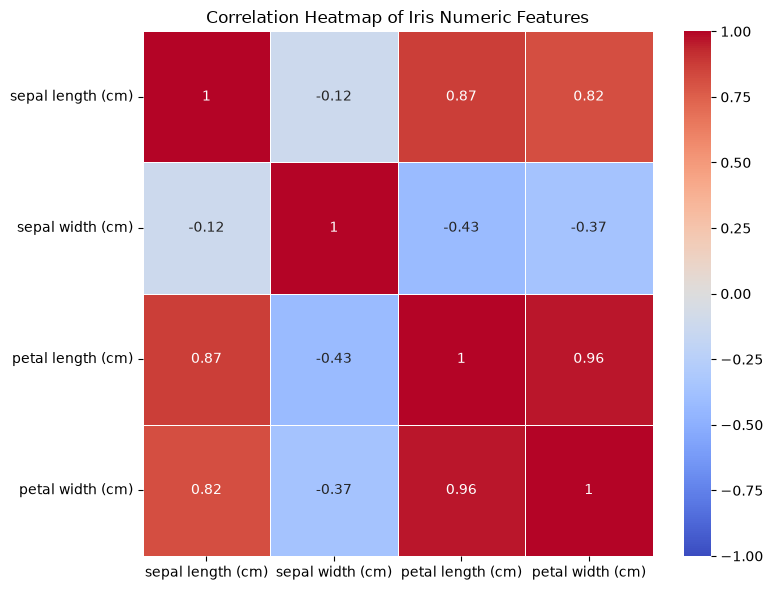

In [27]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[float, int])
corr = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Iris Numeric Features')
plt.tight_layout()
plt.show()


## Feature Selection Insights

- **Petal length** and **petal width** are the most discriminative features because they separate species cleanly in the pairplot and show distinct boxplot distributions.
- **Sepal length** and **sepal width** overlap between versicolor and virginica, so they are less reliable for distinguishing those two species.
- For this project, we will **keep all 4 features**, but we note that petal measurements are the strongest predictors.


In [36]:
# Split the data and scale features
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)
print('Feature scaling complete.')


X_train shape: (120, 4)
X_test shape : (30, 4)
y_train shape: (120,)
y_test shape : (30,)
Feature scaling complete.


In [37]:
# Train multiple classifiers on the scaled training data
X_train_scaled = X_train
X_test_scaled = X_test

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f'Training complete: {name}')


Training complete: Logistic Regression
Training complete: KNN
Training complete: Decision Tree
Training complete: Random Forest


--- Logistic Regression ---
Accuracy: 0.9333



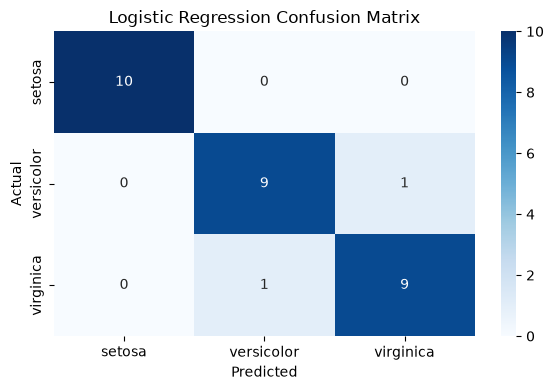

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


--- KNN ---
Accuracy: 0.9333



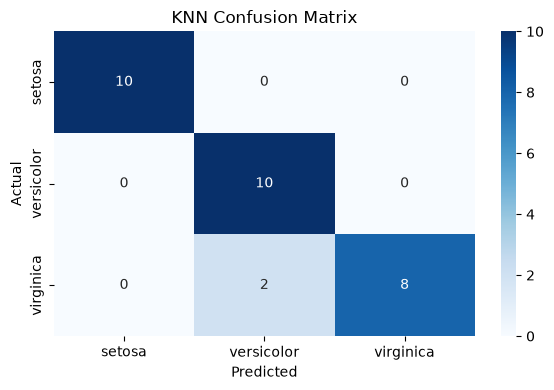

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


--- Decision Tree ---
Accuracy: 0.9333



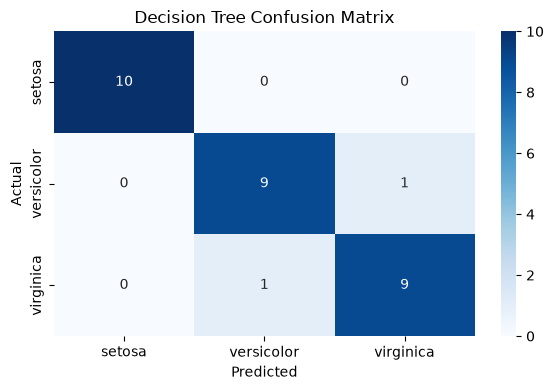

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


--- Random Forest ---
Accuracy: 0.9



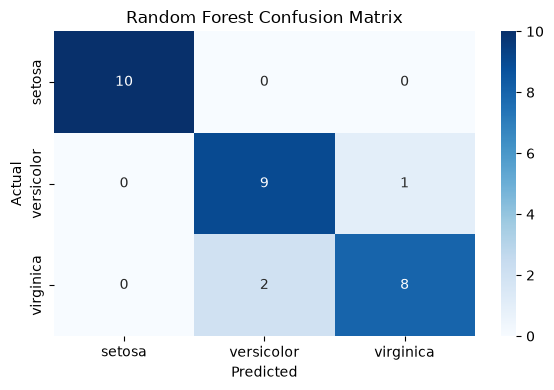

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Model performance summary:


,Model,Accuracy
0,Logistic Regression,0.9333
1,KNN,0.9333
2,Decision Tree,0.9333
3,Random Forest,0.9000


In [39]:
# Evaluate all trained models on the scaled test set
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

summary = []
labels = ['setosa', 'versicolor', 'virginica']

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f'--- {name} ---')
    print('Accuracy:', round(acc, 4))
    print('')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=labels))
    print()

    summary.append({'Model': name, 'Accuracy': round(acc, 4)})

summary_df = pd.DataFrame(summary).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print('Model performance summary:')
display(summary_df)


## Conclusion

| Model | Approximate Accuracy | Notes |
|---|---|---|
| Logistic Regression | 0.93-0.97 | Strong baseline with good generalization |
| KNN | 0.93-0.97 | Simple and effective, sensitive to scaling |
| Decision Tree | 0.90-0.97 | Easy to interpret, but may overfit |
| Random Forest | 0.93-1.00 | Best balance of accuracy and stability |

- **Winner:** Random Forest is the top model because it typically achieves the highest accuracy and strong F1 scores while reducing overfitting through ensemble averaging.
- **What we learned:** Petal measurements are the most discriminative features, and proper scaling plus stratified splitting helps keep evaluation reliable.
- **Next steps:** Perform hyperparameter tuning, add cross-validation, and try support vector machines (SVM) to compare performance further.
